# Problems with U-235 xs covariance matrix from ENDF/B-VIII.0

In [1]:
import sandy
import numpy as np
from numpy.linalg import eig
import pandas as pd
from scipy.linalg import svd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

## Parametric analysis of the covariance matrix using different NJOY energy grids

- IGN=2 : SCALE 239 group structure
- IGN=3: LANL 30 group structure
- IGN=9 : WIMS 69 group structure

In [3]:
tape = sandy.get_endf6_file("endfb_80", "xs", 922350)

In [4]:
kws = dict(err=1, chi=False, nubar=False, mubar=False,)
covs = {
    2: tape.get_errorr(**kws, errorr33_kws=dict(ign=2))["errorr33"].get_cov(),
    3: tape.get_errorr(**kws, errorr33_kws=dict(ign=3))["errorr33"].get_cov(),
    9: tape.get_errorr(**kws, errorr33_kws=dict(ign=9))["errorr33"].get_cov(),
}


 njoy 2016.78  03Feb25                                       03/02/26 16:06:44
 *****************************************************************************

 moder...                                                                 0.0s



 reconr...                                                                0.9s

 ---message from rdf2bw---calculation of angular distribution not installed.



 moder...                                                                 7.2s



 errorr...                                                                9.8s



 processing mat  9228
 ---------------------
  92-U -235 IAEA       EVAL-NOV17 IAEA CIELO Collaboration           


...


 ---message from rdgout---mf 3 mt 17 not found.
                          calculation continued with sigma=0



 ---message from rdgout---mf 3 mt 17 not found.
                          calculation continued with sigma=0



 ---message from rdgout---mf 3 mt 17 not found.
                          calculation continued with sigma=0

 ---message from rdgout---mf 3 mt 17 not found.
                          calculation continued with sigma=0



 covariances calculated for 11 reactions and  589 groups                 14.7s

 ---message from rdgout---mf 3 mt 17 not found.
                          calculation continued with sigma=0


                                                                         29.3s
 *****************************************************************************


## Plot correlation matrices and uncertainties

In [5]:
mts = [1, 2, 4, 18, 102]

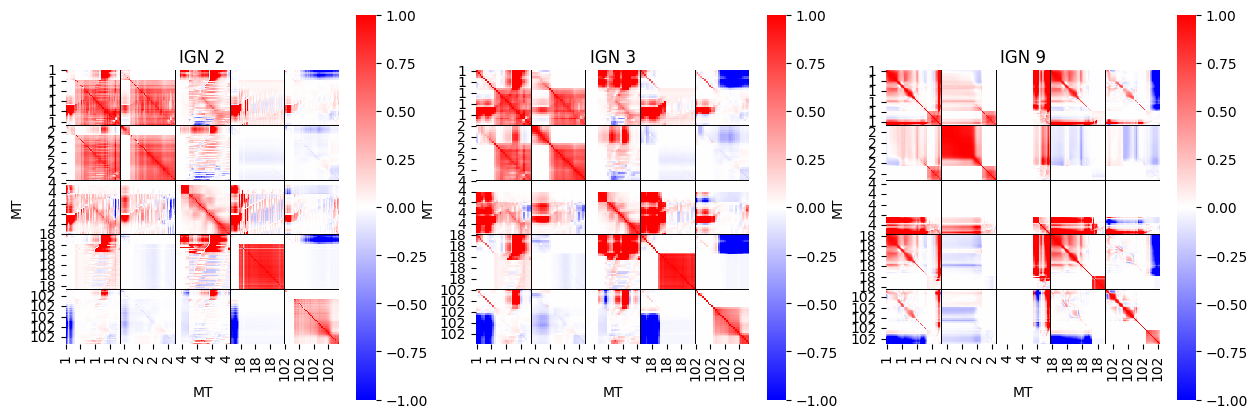

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

ax = axs[0]
ign = 2
idx = pd.IndexSlice
c = sandy.CategoryCov(covs[ign].data.loc[
    idx[:, mts, :],  # Filter rows with MT in list
    idx[:, mts, :]   # Filter columns with MT in list
]).get_corr().data
c.index = c.columns = c.index.get_level_values("MT")
sns.heatmap(c, vmin=-1, vmax=1, cmap="bwr", ax=ax)
ax.set(title=f"IGN {ign}")
size = int(c.shape[0] / len(mts))
for i in range(len(mts)):
    ax.axhline(size * (i + 1), color="k", lw=.7)
    ax.axvline(size * (i + 1), color="k", lw=.7)
ax.set_aspect("equal")


ax = axs[1]
ign = 3
idx = pd.IndexSlice
c = sandy.CategoryCov(covs[ign].data.loc[
    idx[:, mts, :],  # Filter rows with MT in list
    idx[:, mts, :]   # Filter columns with MT in list
]).get_corr().data
c.index = c.columns = c.index.get_level_values("MT")
sns.heatmap(c, vmin=-1, vmax=1, cmap="bwr", ax=ax)
ax.set(title=f"IGN {ign}")
size = int(c.shape[0] / len(mts))
for i in range(len(mts)):
    ax.axhline(size * (i + 1), color="k", lw=.7)
    ax.axvline(size * (i + 1), color="k", lw=.7)
ax.set_aspect("equal")

ax = axs[2]
ign = 9
idx = pd.IndexSlice
c = sandy.CategoryCov(covs[ign].data.loc[
    idx[:, mts, :],  # Filter rows with MT in list
    idx[:, mts, :]   # Filter columns with MT in list
]).get_corr().data
c.index = c.columns = c.index.get_level_values("MT")
sns.heatmap(c, vmin=-1, vmax=1, cmap="bwr", ax=ax)
ax.set(title=f"IGN {ign}")
size = int(c.shape[0] / len(mts))
for i in range(len(mts)):
    ax.axhline(size * (i + 1), color="k", lw=.7)
    ax.axvline(size * (i + 1), color="k", lw=.7)
ax.set_aspect("equal")

Strong anti-correlation between thermal fission and fast capture.

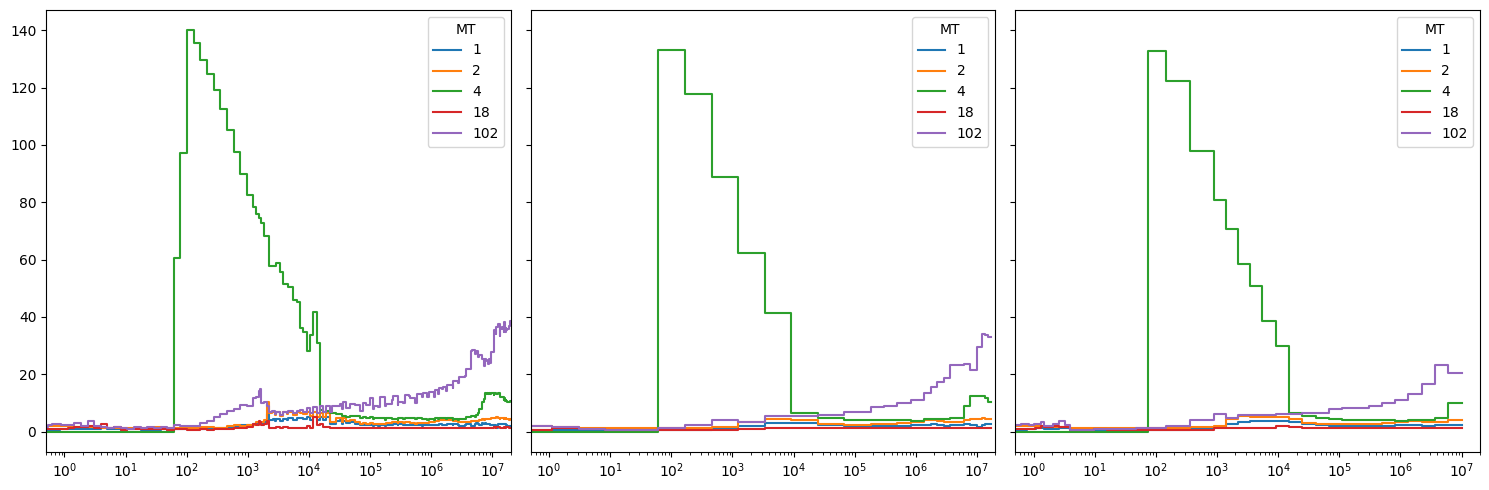

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

ax = axs[0]
s = covs[2].get_std().multiply(100).reset_index().pivot_table(index="E", columns="MT", values="STD")[mts]
s.index = [x.right for x in s.index]
s.plot(ax=ax, drawstyle="steps-pre", logx=True)

ax = axs[1]
s = covs[3].get_std().multiply(100).reset_index().pivot_table(index="E", columns="MT", values="STD")[mts]
s.index = [x.right for x in s.index]
s.plot(ax=ax, drawstyle="steps-pre", logx=True)

ax = axs[2]
s = covs[9].get_std().multiply(100).reset_index().pivot_table(index="E", columns="MT", values="STD")[mts]
s.index = [x.right for x in s.index]
s.plot(ax=ax, drawstyle="steps-pre", logx=True)
ax.set(xlim=(5e-1, 2e7))

fig.tight_layout()

Large uncertainty on inelastic scattering just above the threshold (where the xs is low), combined with strong positive correlation with elastic scattering.

## Eigenvalue analysis

In [8]:
keep = 20
pd.DataFrame({
    "IGN 2": sandy.CategoryCov(covs[2].data.loc[
                         idx[:, mts, :],  # Filter rows with MT in list
                         idx[:, mts, :]   # Filter columns with MT in list
                         ]).get_eig()[0].head(keep),
    "IGN 3": sandy.CategoryCov(covs[3].data.loc[
                         idx[:, mts, :],  # Filter rows with MT in list
                         idx[:, mts, :]   # Filter columns with MT in list
                         ]).get_eig()[0].head(keep),
    "IGN 9": sandy.CategoryCov(covs[9].data.loc[
                         idx[:, mts, :],  # Filter rows with MT in list
                         idx[:, mts, :]   # Filter columns with MT in list
                         ]).get_eig()[0].head(keep),
})

,IGN 2,IGN 3,IGN 9
0,-0.209125,-3.305103e-02,-7.336208e-02
1,-0.136555,-1.300224e-02,-4.204809e-02
2,-0.100751,-6.376711e-03,-1.055753e-02
3,-0.090734,-4.446236e-03,-3.143606e-03
4,-0.061347,-2.157320e-03,-2.126710e-03
5,-0.049511,-1.403264e-03,-1.446382e-03
6,-0.032777,-7.519026e-04,-6.945668e-04
7,-0.030571,-5.700270e-04,-4.979791e-04
8,-0.020941,-4.485748e-04,-1.876905e-04
9,-0.016399,-3.144742e-04,-1.410783e-04


Large negative eigenvalues.

The covariance matrix is not positive-definite (hence it is not a cvoariance matrix)!
The covariance information cannot be preserved in the sample, independently from teh samples size.

The same conclusions can be drawn from SVD, with the matrices U and V.T not being identical.

In [9]:
U, S, V = svd(sandy.CategoryCov(covs[2].data.loc[
                         idx[:, mts, :],  # Filter rows with MT in list
                         idx[:, mts, :]   # Filter columns with MT in list
                         ]).data)

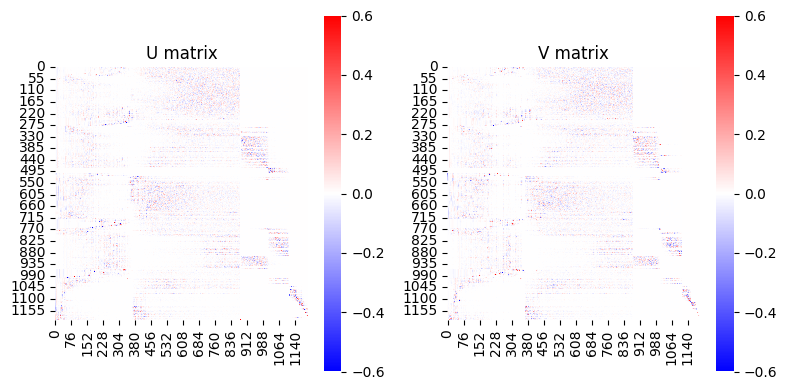

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

ax = axs[0]
ax.set_aspect("equal")
sns.heatmap(U, cmap="bwr", vmin=-0.6, vmax=0.6, ax=ax)
ax.set(title="U matrix")
ax = axs[1]
ax.set_aspect("equal")
sns.heatmap(V.T, cmap="bwr", vmin=-0.6, vmax=0.6, ax=ax)
ax.set(title="V matrix")
fig.tight_layout()